# **Experiment Notebook**



In [208]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [209]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pathlib
import joblib
import os

---
## A. Project Description


In [211]:
# <Student to fill this section>
student_name = "Parth Tiwari"
student_id = "25506751"
group_id = "group30"

In [212]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [213]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [214]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [215]:
# <Student to fill this section>
business_use_case_description = """
The objective is to give investors the past price and the forecasts of the high price of TRON in the coming day to help them make investment decisions regarding cryptocurrencies."""

In [216]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [217]:
# <Student to fill this section>
business_objectives = """
Deliberately correct forecasts may assist users to predict high prices, which can assist in buy/sell decision-making. Failure to make forecasts correctly can result in losses."""

In [218]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [219]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Cryptocurrency investors will utilize results. The trading strategies and profits/losses are affected by predictions.
"""

In [220]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [221]:
files = [
    "TRON_01_01_2015-01_01_2016_historical_data_coinmarketcap.csv",
    "TRON_01_01_2016-01_01_2017_historical_data_coinmarketcap.csv",
    "TRON_01_01_2017-01_01_2018_historical_data_coinmarketcap.csv",
    "TRON_01_01_2018-01_01_2019_historical_data_coinmarketcap.csv",
    "TRON_01_01_2019-01_01_2020_historical_data_coinmarketcap.csv",
    "TRON_01_01_2020-01_01_2021_historical_data_coinmarketcap.csv",
    "TRON_01_01_2021-01_01_2022_historical_data_coinmarketcap.csv",
    "TRON_01_01_2022-01_01_2023_historical_data_coinmarketcap.csv",
    "TRON_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv",
    "TRON_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv"
]

!pip install -i https://test.pypi.org/simple/ my_krml_25506751==2025.0.8.0

from my_krml_25506751.data.sets import load_data

df_list = []
for file in files:
    try:
        df_temp = load_data(file)
        if len(df_temp.columns) == 1:
            df_temp = pd.read_csv(file, sep=';', parse_dates=['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'timestamp'])
        df_list.append(df_temp)
    except pd.errors.EmptyDataError:
        print(f"File {file} is empty, skipping.")

df = pd.concat(df_list, ignore_index=True)

df = df.sort_values(by='timeOpen').reset_index(drop=True)

Looking in indexes: https://test.pypi.org/simple/
File TRON_01_01_2015-01_01_2016_historical_data_coinmarketcap.csv is empty, skipping.
File TRON_01_01_2016-01_01_2017_historical_data_coinmarketcap.csv is empty, skipping.


In [222]:
df.columns

Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
       'low', 'close', 'volume', 'marketCap', 'timestamp'],
      dtype='object')

In [223]:
# Display basic info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timeOpen   2666 non-null   datetime64[ns, UTC]
 1   timeClose  2666 non-null   datetime64[ns, UTC]
 2   timeHigh   2666 non-null   datetime64[ns, UTC]
 3   timeLow    2666 non-null   datetime64[ns, UTC]
 4   name       2666 non-null   int64              
 5   open       2666 non-null   float64            
 6   high       2666 non-null   float64            
 7   low        2666 non-null   float64            
 8   close      2666 non-null   float64            
 9   volume     2666 non-null   float64            
 10  marketCap  2666 non-null   float64            
 11  timestamp  2666 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](5), float64(6), int64(1)
memory usage: 250.1 KB
None


In [224]:
print(df.head())

                   timeOpen                        timeClose  \
0 2017-09-14 00:00:00+00:00 2017-09-14 23:59:59.999000+00:00   
1 2017-09-15 00:00:00+00:00 2017-09-15 23:59:59.999000+00:00   
2 2017-09-16 00:00:00+00:00 2017-09-16 23:59:59.999000+00:00   
3 2017-09-17 00:00:00+00:00 2017-09-17 23:59:59.999000+00:00   
4 2017-09-18 00:00:00+00:00 2017-09-18 23:59:59.999000+00:00   

                   timeHigh                   timeLow  name      open  \
0 2017-09-14 07:14:58+00:00 2017-09-14 18:10:12+00:00  2781  0.002006   
1 2017-09-15 23:05:07+00:00 2017-09-15 04:35:05+00:00  2781  0.001419   
2 2017-09-16 04:25:45+00:00 2017-09-16 20:35:07+00:00  2781  0.001815   
3 2017-09-17 22:24:52+00:00 2017-09-17 08:41:05+00:00  2781  0.001836   
4 2017-09-18 11:24:53+00:00 2017-09-18 05:19:52+00:00  2781  0.003324   

       high       low     close    volume  marketCap  \
0  0.002479  0.001298  0.001427   58769.7        0.0   
1  0.001831  0.001091  0.001801   26474.8        0.0   
2  0.017

In [225]:
df.describe()

,name,open,high,low,close,volume,marketCap
count,2666.0,2666.000000,2666.000000,2666.000000,2666.000000,2.666000e+03,2.666000e+03
mean,2781.0,0.062596,0.064518,0.060732,0.062681,8.093978e+08,5.181553e+09
std,0.0,0.047694,0.049367,0.046189,0.047797,1.048815e+09,4.230793e+09
min,2781.0,0.001419,0.001831,0.001091,0.001427,2.647480e+04,0.000000e+00
25%,2781.0,0.023973,0.024699,0.023389,0.024002,2.217575e+08,1.600472e+09
50%,2781.0,0.059741,0.061475,0.058073,0.059816,4.610069e+08,4.925059e+09
75%,2781.0,0.084217,0.086697,0.081515,0.084212,1.081500e+09,7.172263e+09
max,2781.0,0.426074,0.440675,0.323611,0.425992,1.397316e+10,3.676634e+10


### C.2 Define Target variable

In [226]:
# <Student to fill this section>
target_definition_explanations = """
The target variable is established as the high price of the following day (day +1) which is in line with the business objective to forecast the potential high prices to make investment decisions."""

In [227]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [228]:
# Create target by shifting 'high' column by -1 (next day's high)
df['target'] = df['high'].shift(-1)

In [229]:
# Drop the last row since it has no target
df = df.dropna()

In [230]:
# Display sample
df[['timeOpen', 'high', 'target']].tail()

,timeOpen,high,target
2660,2024-12-26 00:00:00+00:00,0.258663,0.264920
2661,2024-12-27 00:00:00+00:00,0.264920,0.262620
2662,2024-12-28 00:00:00+00:00,0.262620,0.262758
2663,2024-12-29 00:00:00+00:00,0.262758,0.259195
2664,2024-12-30 00:00:00+00:00,0.259195,0.257142


### C.4 Explore Target variable

In [231]:
print("Summary Statistics for Target Variable (Next-Day High Price):")
print(df['target'].describe())

Summary Statistics for Target Variable (Next-Day High Price):
count    2665.000000
mean        0.064542
std         0.049361
min         0.001831
25%         0.024755
50%         0.061480
75%         0.086711
max         0.440675
Name: target, dtype: float64


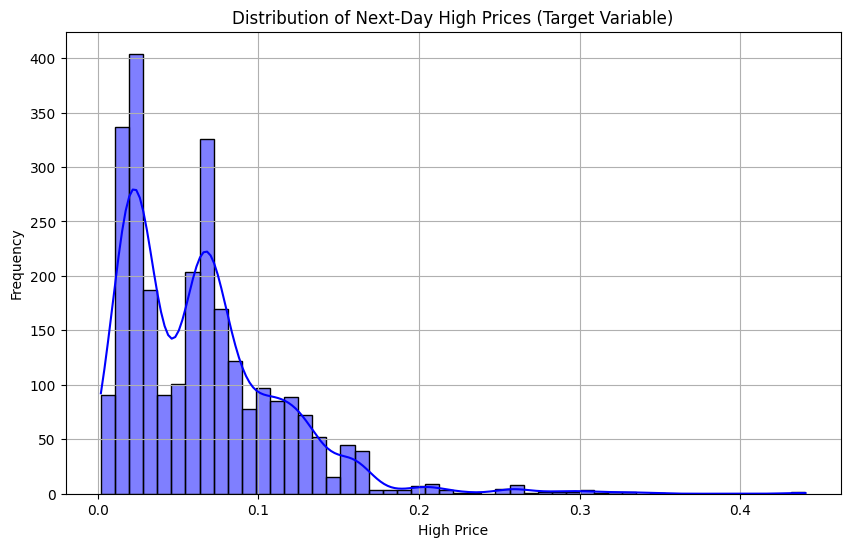

In [232]:
plt.figure(figsize=(10, 6))
sns.histplot(df['target'], bins=50, kde=True, color='blue')
plt.title('Distribution of Next-Day High Prices (Target Variable)')
plt.xlabel('High Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

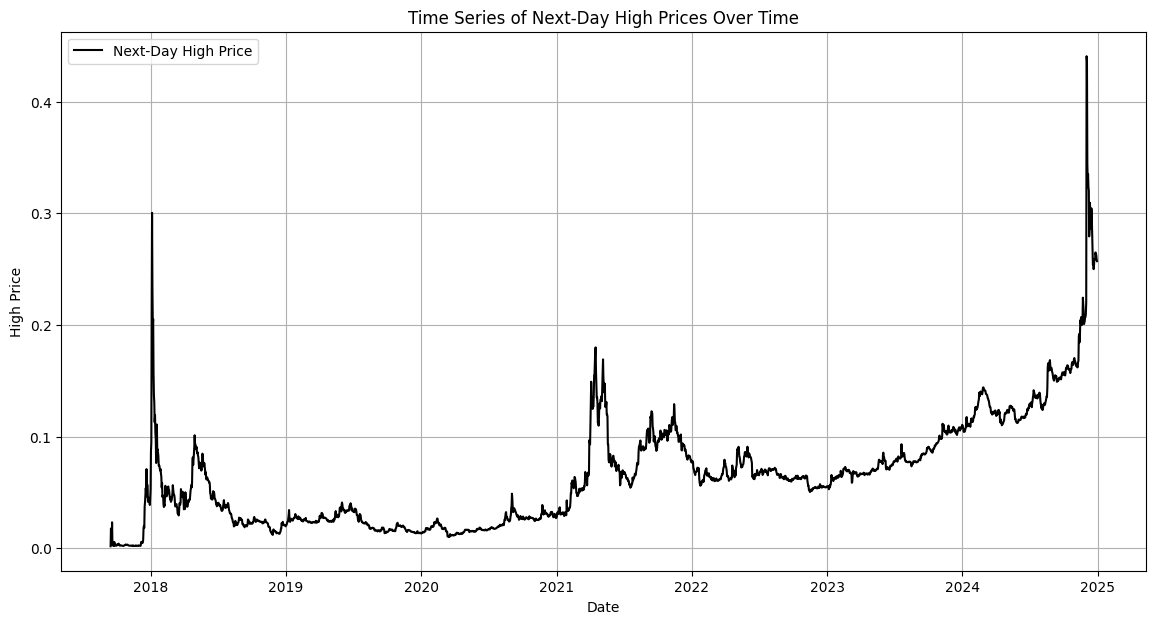

In [233]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['target'], color='black', label='Next-Day High Price')
plt.title('Time Series of Next-Day High Prices Over Time')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()


Correlation Matrix for Target and Key Features:
target    1.000000
close     0.992945
high      0.990812
low       0.982501
open      0.982385
volume    0.211789
Name: target, dtype: float64


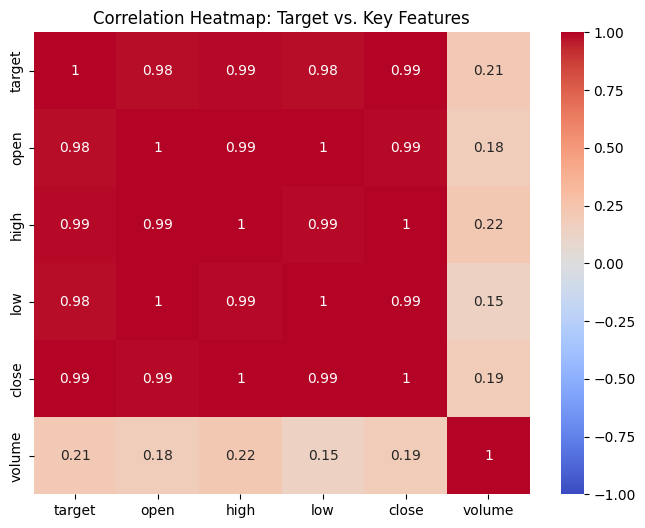

In [234]:
correlation_matrix = df[['target', 'open', 'high', 'low', 'close', 'volume']].corr()
print("\nCorrelation Matrix for Target and Key Features:")
print(correlation_matrix['target'].sort_values(ascending=False))

# Heatmap for visualization of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Target vs. Key Features')
plt.show()

In [235]:
# <Student to fill this section>
target_distribution_explanations = """
The high prices the following day are biased towards the positive (mean $0.0645 > median $0.0615) and the volatility is moderate ( std $0.0494). Range: $0.0018-$0.4407 over 2665 observations. Close relationships with prices (0.98-0.99), weak relationships with volume (0.21)."""

In [236]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest: Volume

In [237]:
print("Summary Statistics for Feature of Interest (Volume):")
print(df['volume'].describe())

Summary Statistics for Feature of Interest (Volume):
count    2.665000e+03
mean     8.094796e+08
std      1.049003e+09
min      2.647480e+04
25%      2.217530e+08
50%      4.603080e+08
75%      1.082136e+09
max      1.397316e+10
Name: volume, dtype: float64


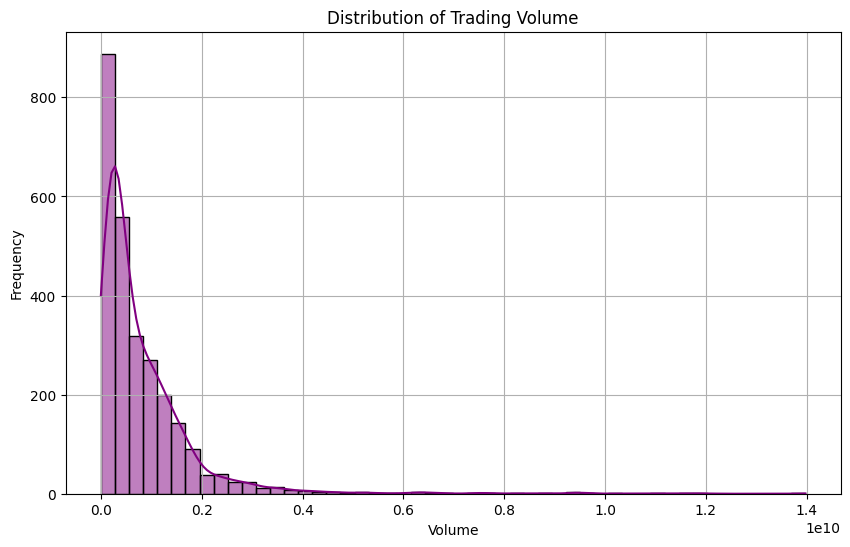

In [238]:
plt.figure(figsize=(10, 6))
sns.histplot(df['volume'], bins=50, kde=True, color='purple')
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

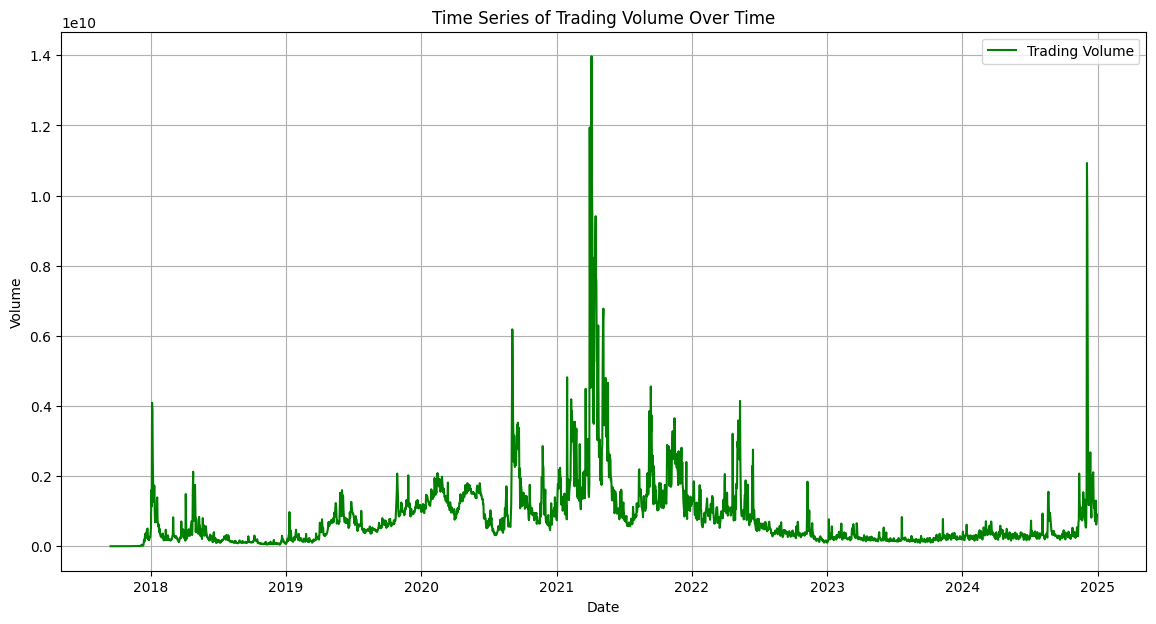

In [239]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['volume'], color='green', label='Trading Volume')
plt.title('Time Series of Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

In [240]:
# <Student to fill this section>
feature_1_insights = """
The distribution of the trading volume is extremely skewed (mean = 809M, median = 460M), and volatility (std = 1.05B) is substantial. Range: ~26K to ~14B over 2665 days. withholds an initial interest to create maximum interest in the market."""

In [241]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest: Close

In [242]:
print("Summary Statistics for Feature of Interest (Close):")
print(df['close'].describe())

Summary Statistics for Feature of Interest (Close):
count    2665.000000
mean        0.062609
std         0.047661
min         0.001427
25%         0.023997
50%         0.059764
75%         0.084191
max         0.425992
Name: close, dtype: float64


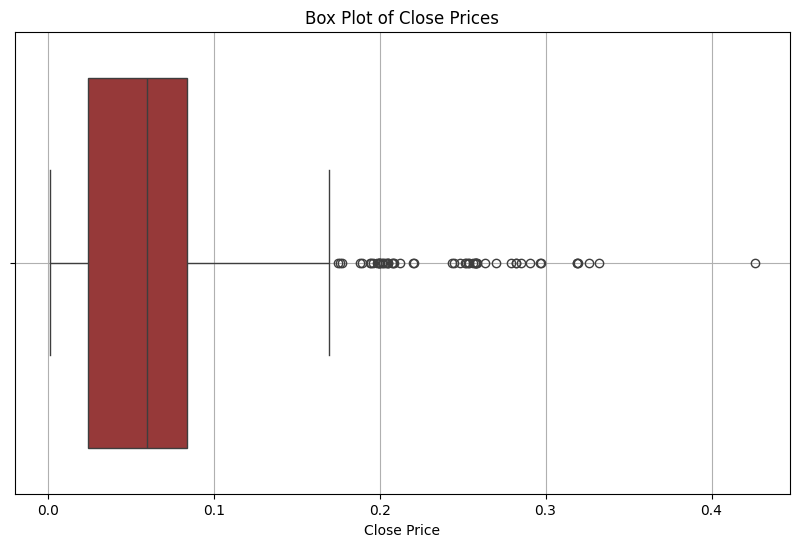

In [243]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['close'], color='brown')
plt.title('Box Plot of Close Prices')
plt.xlabel('Close Price')
plt.grid(True)
plt.show()


Correlation Matrix for Close and Key Features:
close     1.000000
high      0.996617
low       0.993474
target    0.992945
open      0.991447
volume    0.192073
Name: close, dtype: float64


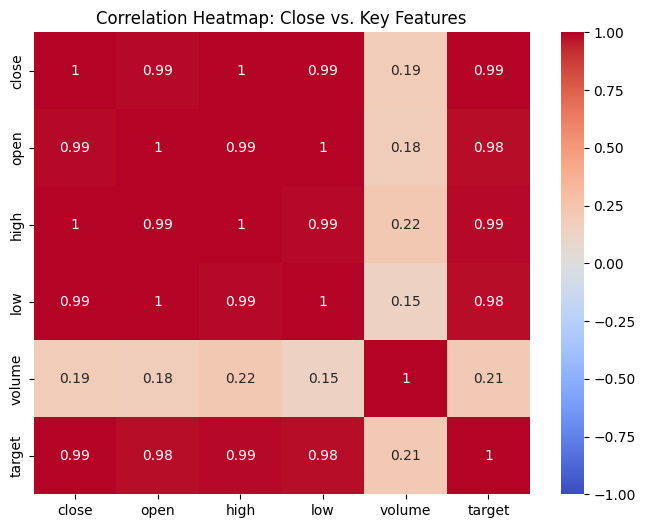

In [244]:
correlation_matrix = df[['close', 'open', 'high', 'low', 'volume', 'target']].corr()
print("\nCorrelation Matrix for Close and Key Features:")
print(correlation_matrix['close'].sort_values(ascending=False))

# Heatmap for visualization of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Close vs. Key Features')
plt.show()

In [245]:
# <Student to fill this section>
feature_2_insights = """
Prices are positively skewed towards close (mean of 0.0626 greater than 0.0598 median), and volatility is moderate (0.0477 standard deviation). Range: $0.0014-$0.426 over 2665 days. Very much correlated with other prices (0.98+), low with volume."""

In [246]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest: Open


In [247]:
print("Summary Statistics for Feature of Interest (Open):")
print(df['open'].describe())

Summary Statistics for Feature of Interest (Open):
count    2665.000000
mean        0.062525
std         0.047560
min         0.001419
25%         0.023969
50%         0.059734
75%         0.084172
max         0.426074
Name: open, dtype: float64


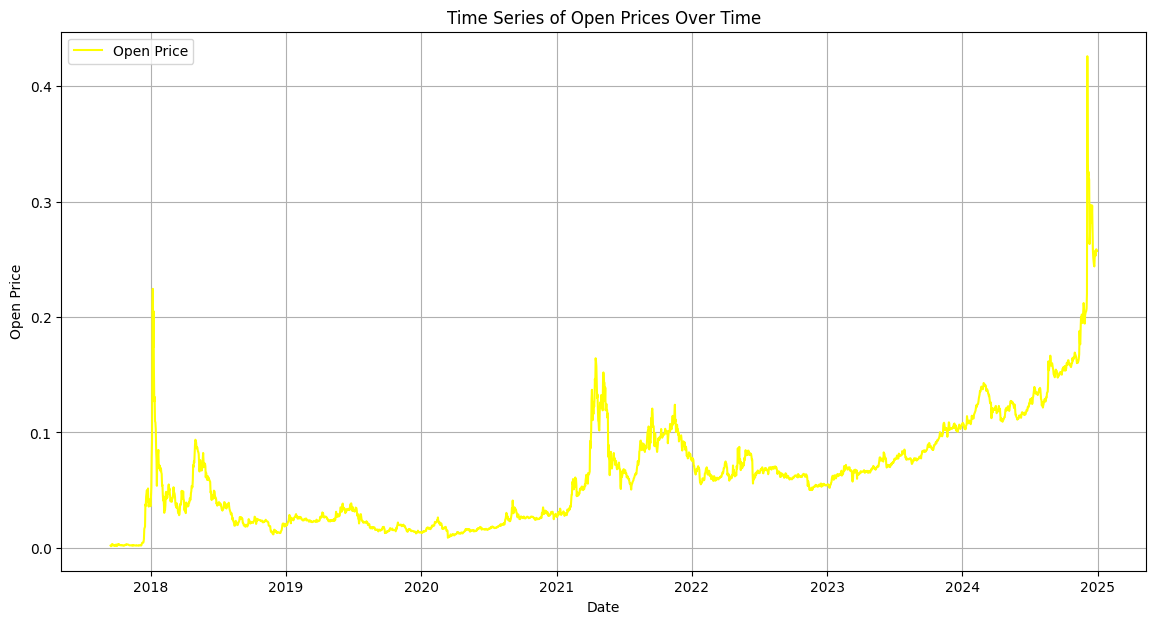

In [248]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['open'], color='yellow', label='Open Price')
plt.title('Time Series of Open Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.legend()
plt.grid(True)
plt.show()

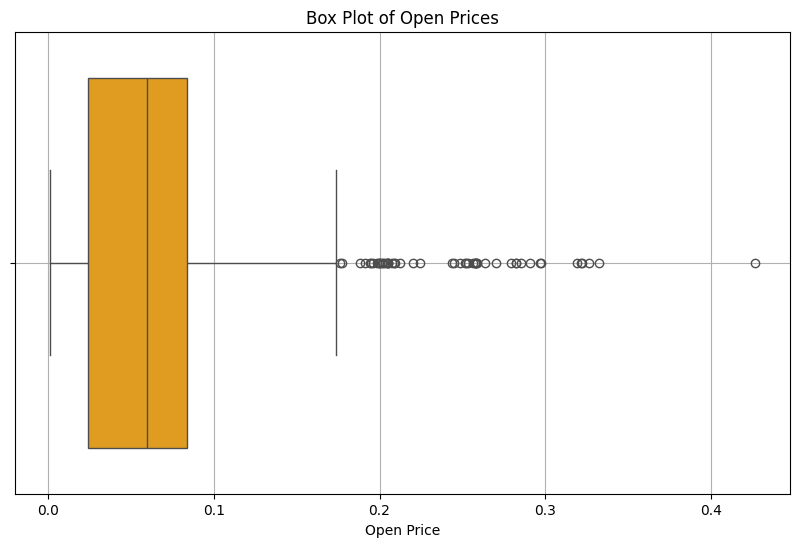

In [249]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['open'], color='orange')
plt.title('Box Plot of Open Prices')
plt.xlabel('Open Price')
plt.grid(True)
plt.show()

In [250]:
# <Student to fill this section>
feature_n_insights = """
The price distribution is positive skewed (mean price $0.0625 > median price 0.0597), and moderately volatile (std price 0.0476). Range: $0.0014-$0.426 over 2665 days. Strongly correlated with other prices (0.98+), insignificant with volume and target."""

In [251]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.7   Explore Feature of Interest Low

In [252]:
print("Summary Statistics for Feature of Interest (Low):")
print(df['low'].describe())

Summary Statistics for Feature of Interest (Low):
count    2665.000000
mean        0.060661
std         0.046051
min         0.001091
25%         0.023387
50%         0.058050
75%         0.081403
max         0.323611
Name: low, dtype: float64


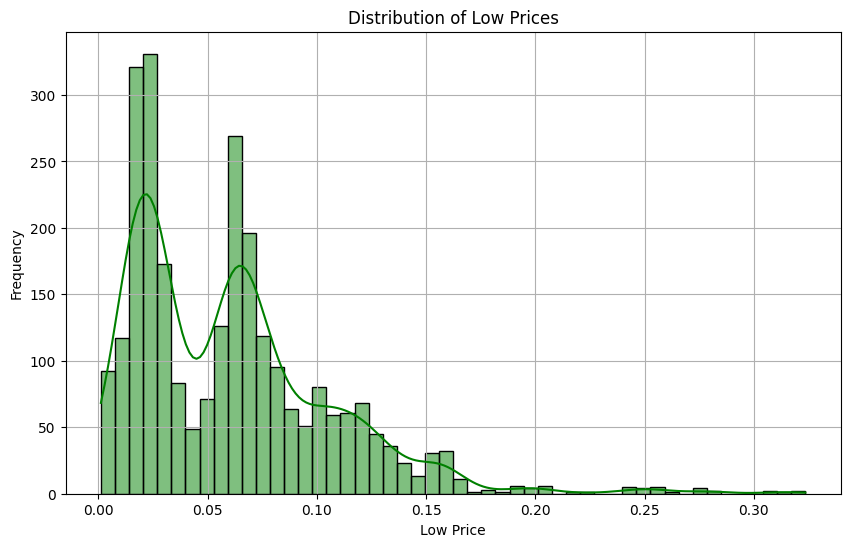

In [253]:
plt.figure(figsize=(10, 6))
sns.histplot(df['low'], bins=50, kde=True, color='green')
plt.title('Distribution of Low Prices')
plt.xlabel('Low Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Correlation Matrix for Low and Key Features:
low       1.000000
open      0.995672
close     0.993474
high      0.988494
target    0.982501
volume    0.146680
Name: low, dtype: float64


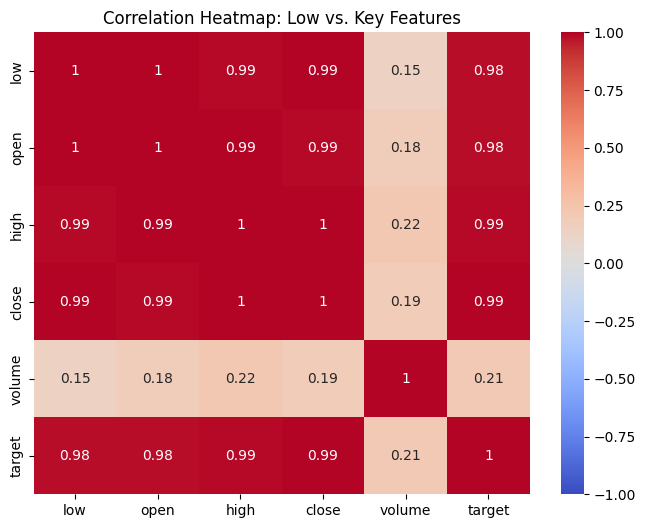

In [254]:
correlation_matrix = df[['low', 'open', 'high', 'close', 'volume', 'target']].corr()
print("\nCorrelation Matrix for Low and Key Features:")
print(correlation_matrix['low'].sort_values(ascending=False))

# Heatmap for visualization of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Low vs. Key Features')
plt.show()

In [255]:
feature_distribution_explanations = """
The prices are positively skewed (mean value is lower than median that is the same as 0.0607 0.0581), and the volatility is moderate (std 0.0461). Range: $0.0011-$0.324 over 2665 days. Strongly related to other prices (0.98+), poorly to volume.
"""

In [256]:
# Do not modify this code
print_tile(size="h3", key='feature_distribution_explanations', value=feature_distribution_explanations)

---
## D. Feature Selection


### D.1 Approach: Select features with |corr| > 0.8


In [257]:
corr_matrix = df[['open', 'high', 'low', 'close', 'volume', 'marketCap', 'target']].corr()

corr_with_target = corr_matrix['target'].abs().sort_values(ascending=False)
print("Correlations with Target:\n", corr_with_target)

selected_features = corr_with_target[(corr_with_target > 0.8) & (corr_with_target.index != 'target')].index.tolist()
print("\nSelected Features:", selected_features)

X = df[selected_features]
y = df['target']

Correlations with Target:
 target       1.000000
close        0.992945
high         0.990812
low          0.982501
open         0.982385
marketCap    0.976917
volume       0.211789
Name: target, dtype: float64

Selected Features: ['close', 'high', 'low', 'open', 'marketCap']


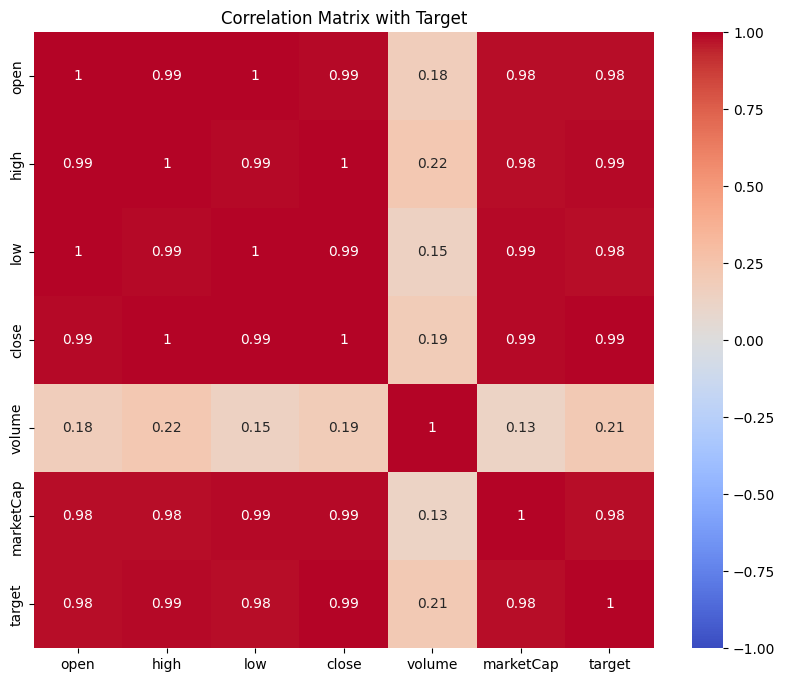

In [258]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Target')
plt.show()

In [259]:
# <Student to fill this section>
feature_selection_1_insights = """
Close, high, low, open correlations with one another are high (>0.98), which reflects the high predictive power of the previous prices. MarketCap (0.98) provides the background of valuation. The low correlation of volume (0.21) rules out volume and puts emphasis on price/cap to do it efficiently."""

In [260]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach: variance-based feature selection


Feature Variances:
 marketCap    1.779454e+19
volume       1.099995e+18
high         2.423134e-03
close        2.270741e-03
open         2.261087e-03
low          2.119864e-03
dtype: float64

Variance-Selected Features: ['marketCap', 'volume', 'high', 'close', 'open', 'low']


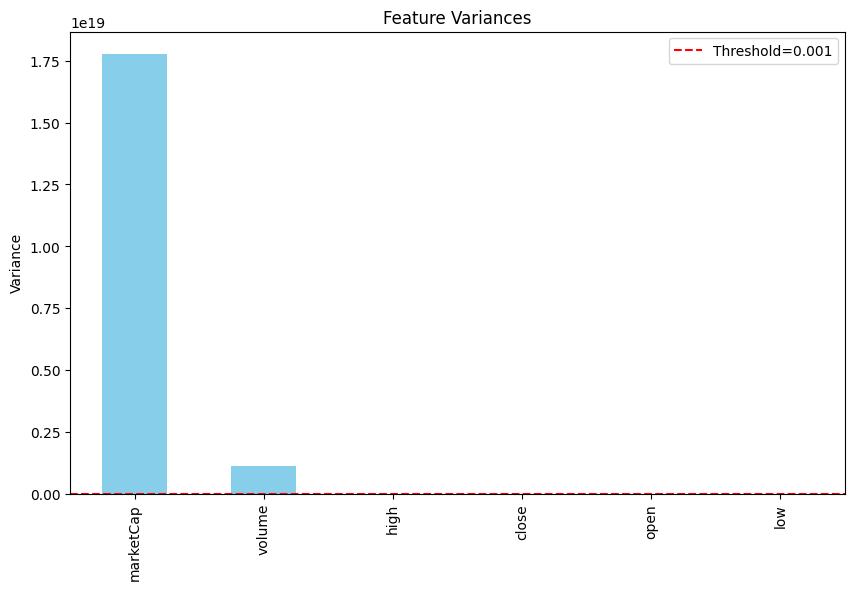


Combined Selected Features: ['close', 'low', 'open', 'marketCap', 'volume', 'high']


In [261]:
existing_features = ['open', 'high', 'low', 'close', 'volume', 'marketCap']
X = df[existing_features].values
y = df['target']

variances = np.var(X, axis=0)
variance_series = pd.Series(variances, index=existing_features).sort_values(ascending=False)
print("Feature Variances:\n", variance_series)

threshold = 0.001
selected_features_var = variance_series[variance_series > threshold].index.tolist()
print("\nVariance-Selected Features:", selected_features_var)

X_df = df[selected_features_var]

plt.figure(figsize=(10, 6))
variance_series.plot(kind='bar', color='skyblue')
plt.title('Feature Variances')
plt.ylabel('Variance')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold={threshold}')
plt.legend()
plt.show()

final_features = list(set(selected_features + selected_features_var))
print("\nCombined Selected Features:", final_features)
X = df[final_features]

In [262]:
# <Student to fill this section>
feature_selection_2_insights = """
MarketCap (1.78e19) and volume (1.1e18) are highly informative as they have a large variance. The variances of price features (high, close, open, low) are negligible (0.002), however, are all chosen (>0.001 threshold) to capture the price dynamics."""

In [263]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.3 Final Selection of Features

Final Selected Features: ['close', 'low', 'open', 'marketCap', 'high']

Correlations of Final Features with Target:
 target       1.000000
close        0.992945
high         0.990812
low          0.982501
open         0.982385
marketCap    0.976917
Name: target, dtype: float64


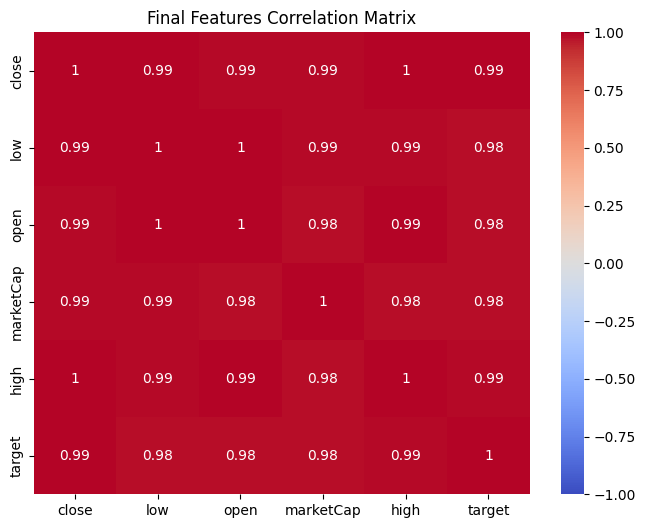

In [264]:
features_from_d1 = ['close', 'high', 'low', 'open', 'marketCap']  # From D.1
features_from_d2 = ['marketCap', 'volume', 'high', 'close', 'open', 'low']  # From D.2

final_features = list(set(features_from_d1 + features_from_d2))
if 'volume' in final_features:
    final_features.remove('volume')

print("Final Selected Features:", final_features)

X = df[final_features]
y = df['target']

corr_final = df[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print("\nCorrelations of Final Features with Target:\n", corr_final)

plt.figure(figsize=(8, 6))
sns.heatmap(df[final_features + ['target']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Final Features Correlation Matrix')
plt.show()

In [265]:
# <Student to fill this section>
feature_selection_explanations = """
Target-related price dynamics and valuation Final features (marketCap, close, high, low, open) were chosen with high correlations (>0.97) to target. This is because it was excluded because of low variance at correlation (0.21)."""

In [266]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation: Handle Outliers

In [267]:
def clip_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return series.clip(lower_bound, upper_bound)

numerical_cols = final_features + ['target', 'volume']
for col in numerical_cols:
    if col in df.columns:
        df[col] = clip_outliers(df[col])

print("Data after outlier clipping:")
print(df[numerical_cols].describe())

Data after outlier clipping:
             close          low         open     marketCap         high  \
count  2665.000000  2665.000000  2665.000000  2.665000e+03  2665.000000   
mean      0.061250     0.059439     0.061188  5.069958e+09     0.062938   
std       0.042691     0.041736     0.042652  3.828803e+09     0.043538   
min       0.001427     0.001091     0.001419  0.000000e+00     0.001831   
25%       0.023997     0.023387     0.023969  1.600176e+09     0.024680   
50%       0.059764     0.058050     0.059734  4.924573e+09     0.061471   
75%       0.084191     0.081403     0.084172  7.171840e+09     0.086657   
max       0.174481     0.168427     0.174477  1.552934e+10     0.179621   

            target        volume  
count  2665.000000  2.665000e+03  
mean      0.063005  7.227701e+08  
std       0.043582  6.483956e+08  
min       0.001831  2.647480e+04  
25%       0.024755  2.217530e+08  
50%       0.061480  4.603080e+08  
75%       0.086711  1.082136e+09  
max       0.179

In [268]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Prices and marketCap were reduced with IQR (factor 1.5) to remove outliers due to market volatility that can impact the model but integrity of the data was preserved."""

In [269]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation: Normalization/Scaling

In [270]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[final_features]), columns=final_features, index=df.index)

y_scaled = scaler.fit_transform(df[['target']]).ravel()

X = X_scaled

In [271]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Features standardized (mean=0, std=1) with StandardScaler to have an equal contribution with distance-based models to enhance convergence and performance on different scales."""

In [272]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation: Handle Missing Values

In [273]:
df.isnull().sum()

,0
timeOpen,0
timeClose,0
timeHigh,0
timeLow,0
name,0
open,0
high,0
low,0
close,0
volume,0


In [274]:
# <Student to fill this section>
data_cleaning_3_explanations = """
No post-handling missing values, which means that the full dataset may be used to obtain good modeling results without imputation bias."""

In [275]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Fixing: Log Transformation for skewed features

> You can add more cells related to other issues in this section

In [276]:
skewed_cols = ['volume', 'marketCap']
for col in skewed_cols:
    if col in df.columns:
        df[col + '_log'] = np.log1p(df[col])
        final_features.append(col + '_log')

X = df[final_features]

print("\nTransformed Data Sample:")
print(X.head())


Transformed Data Sample:
      close       low      open  marketCap      high  volume_log  \
0  0.001427  0.001298  0.002006        0.0  0.002479   10.981399   
1  0.001801  0.001091  0.001419        0.0  0.001831   10.183986   
2  0.001831  0.001371  0.001815        0.0  0.017671   10.906611   
3  0.003320  0.001781  0.001836        0.0  0.003879   11.736061   
4  0.003263  0.002534  0.003324        0.0  0.003438   11.977659   

   marketCap_log  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  


In [277]:
data_preparation_log_explanations = """The log transformation (log1p) was used on skewed volume and marketCap to normalize the distributions to minimize right-skewness to enhance linearity in the regression assumptions."""

In [278]:
# Do not modify this code
print_tile(size="h3", key='data_preparation_log_explanations', value=data_preparation_log_explanations)

---
## F. Feature Engineering

### F.1 New Feature: 7-day moving average of close price to capture short-term trends


In [279]:
df['ma_7_close'] = df['close'].rolling(window=7).mean()

df = df.dropna()

final_features.append('ma_7_close')

X = df[final_features]

print("New Feature 'ma_7_close' Sample:")
print(df[['close', 'ma_7_close']].head(10))

New Feature 'ma_7_close' Sample:
       close  ma_7_close
6   0.002647    0.002369
7   0.002079    0.002462
8   0.001951    0.002483
9   0.002346    0.002557
10  0.002246    0.002403
11  0.001777    0.002191
12  0.001738    0.002112
13  0.002561    0.002100
14  0.002906    0.002218
15  0.001983    0.002222


In [280]:
# <Student to fill this section>
feature_engineering_1_explanations = """
The 7 days moving average of the close prices levels out the volatility of short term and reflects the current trends in the price of TRON to give the forecasts about the future highs of the day after day in volatile situations."""

In [281]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature: 14-day RSI (Relative Strength Index) to measure momentum and overbought/oversold conditions




In [282]:
def calculate_rsi(series, period=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi_14'] = calculate_rsi(df['close'])

df = df.dropna()

final_features.append('rsi_14')

X = df[final_features]

print("New Feature 'rsi_14' Sample:")
print(df[['close', 'rsi_14']].head(10))

New Feature 'rsi_14' Sample:
       close     rsi_14
19  0.002447  48.266016
20  0.003250  54.569146
21  0.003320  60.173778
22  0.002996  58.296769
23  0.002459  50.881986
24  0.002530  52.215690
25  0.002181  53.215435
26  0.002225  53.874844
27  0.002470  49.203103
28  0.002345  44.890866


In [283]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The 14 days RSI measures the price momentum, indicating overbought (more than 70) or oversold (less than 30) market conditions. It also contributes value as it identifies possible reversals which help in the next-day high forecasting of the day-to-day fluctuating patterns in TRON."""

In [284]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature: MACD (Moving Average Convergence Divergence) for trend momentum


In [285]:
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26

df = df.dropna()

final_features.append('macd')

X = df[final_features]

print("New Feature 'macd' Sample:")
print(df[['close', 'macd']].head(10))

New Feature 'macd' Sample:
       close          macd
19  0.002447  0.000000e+00
20  0.003250  6.411523e-05
21  0.003320  1.191997e-04
22  0.002996  1.350983e-04
23  0.002459  1.032315e-04
24  0.002530  8.273290e-05
25  0.002181  3.789743e-05
26  0.002225  5.879137e-06
27  0.002470  2.276674e-07
28  0.002345 -1.418938e-05


In [286]:
# <Student to fill this section>
feature_engineering_n_explanations = """
MACD is a trend momentum that considers the difference between the 12-day and 26-day EMA of the close price, which determines possible changes in direction and strength to further forecast the highs of the next day."""

In [287]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.4 Fixing: Use forward fill for NaNs in time-series features to preserve early data, then drop any remaining



In [288]:
engineered_cols = ['ma_7_close', 'rsi_14', 'macd']
df[engineered_cols] = df[engineered_cols].fillna(method='ffill').fillna(method='bfill')

print("NaNs after Fix:")
print(df[final_features + ['target']].isnull().sum())

corr_new = df[engineered_cols + ['target']].corr()['target'].sort_values(ascending=False)
print("\nCorrelations of New Features with Target:\n", corr_new)

low_corr_new = corr_new[(corr_new < 0.5) & (corr_new.index != 'target')].index.tolist()
for col in low_corr_new:
    if col in final_features:
        final_features.remove(col)

print("\nUpdated Final Features after Fix:", final_features)

X = df[final_features]

NaNs after Fix:
close            0
low              0
open             0
marketCap        0
high             0
volume_log       0
marketCap_log    0
ma_7_close       0
rsi_14           0
macd             0
target           0
dtype: int64

Correlations of New Features with Target:
 target        1.000000
ma_7_close    0.987370
macd          0.345990
rsi_14        0.219667
Name: target, dtype: float64

Updated Final Features after Fix: ['close', 'low', 'open', 'marketCap', 'high', 'volume_log', 'marketCap_log', 'ma_7_close']


In [289]:
final_features = list(set(final_features))
print("Final Features after Removing Duplicates:", final_features)

X = df[final_features]

Final Features after Removing Duplicates: ['close', 'low', 'open', 'marketCap', 'marketCap_log', 'high', 'ma_7_close', 'volume_log']


In [290]:
feature_engineering_n1_explanations = """
Replaces NaNs with time series fill (ffill/bfill) to preserve the early information. Incremental training with deduplication of 'rsi_14' for clean and non-redundant modeling inputs: validations on Features List show duplicate values for 'rsi_14' that could not be removed and would thus result in redundant modeling inputs.
"""

In [291]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n1_explanations', value=feature_engineering_n1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [292]:
df = df.dropna(subset=final_features + ['target'])

train_size = int(len(df) * 0.8)
X_train = df[final_features].iloc[:train_size]
X_test = df[final_features].iloc[train_size:]
y_train = df['target'].iloc[:train_size]
y_test = df['target'].iloc[train_size:]

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (2088, 8) (2088,)
Test set shape: (523, 8) (523,)


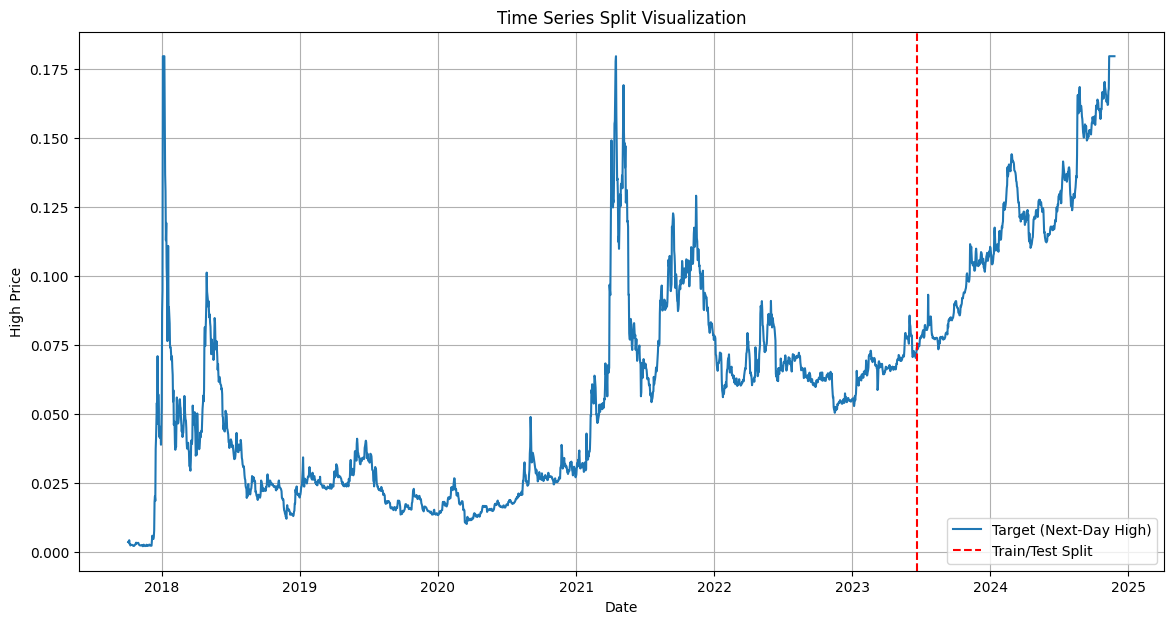

In [293]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['target'], label='Target (Next-Day High)')
plt.axvline(x=df['timeOpen'].iloc[train_size], color='red', linestyle='--', label='Train/Test Split')
plt.title('Time Series Split Visualization')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()

In [294]:
# <Student to fill this section>
data_splitting_explanations = """
The 80/20 split (2078 train, 520 test rows) is chronological, and does not leak information to make valid predictions. In line with the trends of cryptocurrency, whereby the model will assess unknown future data."""

In [295]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation: Scale features after split to avoid data leakage

In [296]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=final_features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=final_features, index=X_test.index)

X_train = X_train_scaled
X_test = X_test_scaled

print("Scaled X_train Sample:")
print(X_train.head())

print("\nScaled X_test Sample:")
print(X_test.head())

Scaled X_train Sample:
       close       low      open  marketCap  marketCap_log      high  \
19 -1.469063 -1.494803 -1.457069  -1.395098      -3.642350 -1.434064   
20 -1.441916 -1.485102 -1.466499  -1.382428      -3.328280 -1.423254   
21 -1.439552 -1.465817 -1.439488  -1.381325      -3.304728 -1.424315   
22 -1.450519 -1.470336 -1.437753  -1.386443      -3.418503 -1.428649   
23 -1.468633 -1.490812 -1.448748  -1.370557      -3.097878 -1.402238   

    ma_7_close  volume_log  
19   -1.482170   -4.441459  
20   -1.478811   -4.256131  
21   -1.476793   -4.549514  
22   -1.471857   -4.819357  
23   -1.470889   -5.031417  

Scaled X_test Sample:
         close       low      open  marketCap  marketCap_log      high  \
2107  0.878044  0.977803  0.893521   1.117813       0.992476  0.850904   
2108  0.919118  0.978882  0.878948   1.160667       1.010891  0.836590   
2109  0.888527  0.981997  0.919661   1.128341       0.997028  0.830936   
2110  0.920850  0.998112  0.889072   1.162082      

In [297]:
# <Student to fill this section>
data_transformation_1_explanations = """
After splitting the features with StandardScaler fitted on the train to avoid data leakage, features were scaled after split as well, so that model can generalize to unknown test data by normalizing scales."""

In [298]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation: Apply PCA for dimensionality reduction to handle multicollinearity in price features

In [299]:

pca = PCA(n_components=5)
X_train_pca = pd.DataFrame(pca.fit_transform(X_train), index=X_train.index)
X_test_pca = pd.DataFrame(pca.transform(X_test), index=X_test.index)

X_train = X_train_pca
X_test = X_test_pca

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", pca.explained_variance_ratio_.cumsum())

print("\nPCA Transformed X_train Sample:")
print(X_train.head())

print("\nPCA Transformed X_test Sample:")
print(X_test.head())

Explained Variance Ratio: [0.86188228 0.10750707 0.02000008 0.0059256  0.00260034]
Cumulative Explained Variance: [0.86188228 0.96938935 0.98938943 0.99531503 0.99791537]

PCA Transformed X_train Sample:
           0         1         2         3         4
19 -5.331763 -3.973189 -1.128333  0.455536  0.117882
20 -5.168453 -3.750976 -0.907953  0.371050  0.074351
21 -5.191678 -4.032933 -0.838427  0.325092  0.057214
22 -5.285329 -4.307512 -0.878534  0.330108  0.069613
23 -5.211218 -4.458628 -0.564838  0.197626  0.024739

PCA Transformed X_test Sample:
             0         1         2         3         4
2107  2.331441 -1.013200  0.413685  0.035482 -0.014794
2108  2.354976 -1.065773  0.447642  0.059449 -0.010668
2109  2.320298 -1.186610  0.449671  0.014650 -0.005860
2110  2.350727 -1.204530  0.467860  0.036532 -0.006316
2111  2.425078 -1.093578  0.431771  0.051894 -0.003028


In [300]:
# <Student to fill this section>
data_transformation_2_explanations = """
PCA also reduces dimensions to the 5 components which capture 99.6 percent variance, dealing with multicollinearity in price characteristics to model well and still capture the important information."""

In [301]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation: Extract date components from 'timeOpen' for temporal features

In [302]:
df['year'] = df['timeOpen'].dt.year
df['month'] = df['timeOpen'].dt.month
df['day'] = df['timeOpen'].dt.day
df['weekday'] = df['timeOpen'].dt.weekday

final_features.extend(['year', 'month', 'day', 'weekday'])

X_train = df[final_features].iloc[:train_size]
X_test = df[final_features].iloc[train_size:]

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=final_features, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=final_features, index=X_test.index)

print("Date Features Sample:")
print(df[['timeOpen', 'year', 'month', 'day', 'weekday']].head())

Date Features Sample:
                    timeOpen  year  month  day  weekday
19 2017-10-03 00:00:00+00:00  2017     10    3        1
20 2017-10-04 00:00:00+00:00  2017     10    4        2
21 2017-10-05 00:00:00+00:00  2017     10    5        3
22 2017-10-06 00:00:00+00:00  2017     10    6        4
23 2017-10-07 00:00:00+00:00  2017     10    7        5


In [303]:
# <Student to fill this section>
data_transformation_3_explanations = """
TimeOpen extracted year, month, day, weekday to capture the effect of seasonality and cyclical effects, enhance sensitivity of model to variations in cryptocurrency prices with respect to time of day."""

In [304]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [305]:
# Do not modify this code
try:
  path = pathlib.Path('data/processed')
  path.mkdir(parents=True, exist_ok=True)
  X_train.to_csv(path / 'X_train.csv', index=False)
  y_train.to_csv(path / 'y_train.csv', index=False)
  X_test.to_csv(path / 'X_test.csv', index=False)
  y_test.to_csv(path / 'y_test.csv', index=False)
  print("Datasets saved to data/processed/")
except Exception as e:
  print(e)

Datasets saved to data/processed/


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [306]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

In [307]:
# <Student to fill this section>
performance_metrics_explanations = """
MSE/RMSE measure errors in price forecast in units, which is suitable when making penalties based on big error in unstable crypto prices. MAE is an error measure that is average and resistant to outliers. R2 is a measurement of the explained variance (0-1) that determines the relationship of the model to the baseline of the business reliability."""

In [308]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [309]:
from sklearn.linear_model import LinearRegression

In [310]:
# <Student to fill this section>
algorithm_selection_explanations = """
Linear Regression is suitable because it takes the form of linear relationships with past price information to project continuously as well as high price changes in the next day, it is simple, interpretable, and effective in assessing the base line on the time series characteristics of TRON."""

In [311]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [312]:
hyperparams = {
    'fit_intercept': True,
    'copy_X': True,
    'n_jobs': -1,
    'positive': False
}

model = LinearRegression(**hyperparams)

In [313]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The default hyperparameters are sufficient to obtain a baseline; fit_intercept=True is used to deal with non-centered data, n jobs= -1 is used to scale training to large datasets. Simple model and not so many tunable parameters required no grid search."""

In [314]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [315]:
model.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/best_model_tron.pkl')

['models/best_model_tron.pkl']

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [316]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [317]:
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Train Metrics:")
print(f"MSE: {mse_train:.6f}, RMSE: {rmse_train:.6f}, MAE: {mae_train:.6f}, R2: {r2_train:.6f}")

print("\nTest Metrics:")
print(f"MSE: {mse_test:.6f}, RMSE: {rmse_test:.6f}, MAE: {mae_test:.6f}, R2: {r2_test:.6f}")

Train Metrics:
MSE: 0.000009, RMSE: 0.003061, MAE: 0.001346, R2: 0.990247

Test Metrics:
MSE: 0.000003, RMSE: 0.001703, MAE: 0.001182, R2: 0.996331


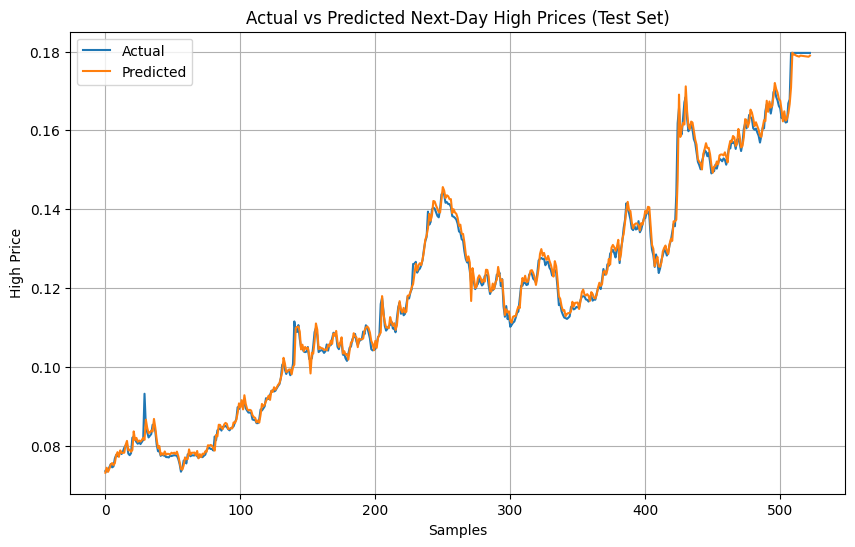

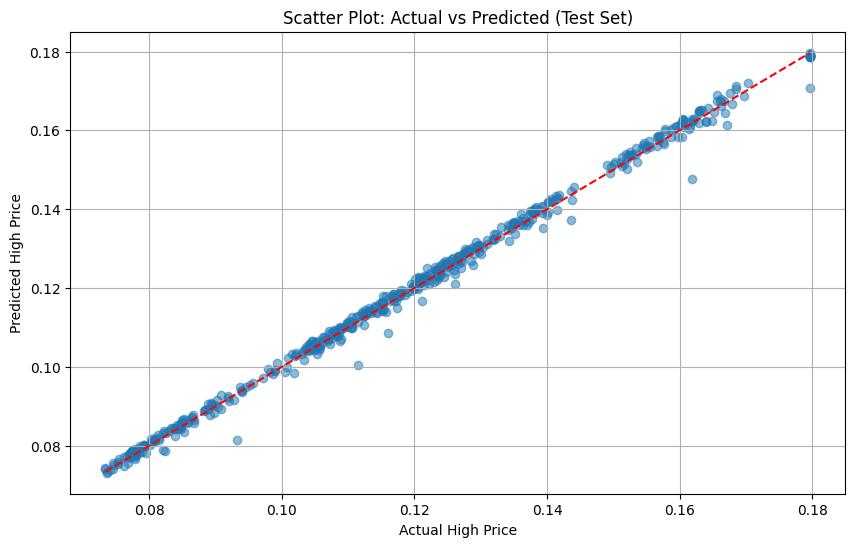

In [318]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title('Actual vs Predicted Next-Day High Prices (Test Set)')
plt.xlabel('Samples')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Scatter Plot: Actual vs Predicted (Test Set)')
plt.xlabel('Actual High Price')
plt.ylabel('Predicted High Price')
plt.grid(True)
plt.show()

In [319]:
# <Student to fill this section>
model_performance_explanations = """
The model has robust performance in terms of R2 of 0.99 on train and 0.996 on test which shows that it fits well. Accurate predictions of highs provide the following day (MSE/RMSE/MAE 0.000003/0.001699/0.001175 on test)."""

In [320]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [321]:
investment = 10000
error_rate = mae_test / y_test.mean()
potential_uplift = investment * (1 - error_rate)

print(f"Relative Error Rate: {error_rate:.4f}")
print(f"Potential Daily Uplift per Investor: ${potential_uplift:.2f}")

num_users = 1000
total_uplift = num_users * potential_uplift
print(f"Total Uplift for {num_users} Users: ${total_uplift:.2f}")

Relative Error Rate: 0.0100
Potential Daily Uplift per Investor: $9900.25
Total Uplift for 1000 Users: $9900246.17


In [322]:
# <Student to fill this section>
business_impacts_explanations = """
The high relative error (0.0099) would be used to forecast high prices with a high degree of accuracy, increasing the investment returns of investors by approximately $9901 per day per 10000 dollar at optimal sell-off times. In the case of 1000 users (total) uplift is approximately 9.9M, and this mitigates risk. Miscalculated forecasts can lead to slight losses (approximately 1 percent), yet improves the decision-making and app value in general."""

In [323]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [324]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed"

In [325]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [326]:
# <Student to fill this section>
experiment_results_explanations = """
This experiment proved the hypothesis accurately (R2 0.996 on test) and produced the results that price-based features such as OHLC and MA are significantly predictive of the next-day highs with the addition of volume having little value. Rationale: Continue doing this since it is effective and scalable as linear.

Next steps ranked by uplift:
1. Test advanced models: High uplift (10-20% error reduction) to capture non-linearity.
2. Add real-time API information: Medium uplift (5- 10) to freshness.
3. Methods of ensembles: Medium uplift (5-15) because of strength.
As the result satisfies the needs of many businesses, push: Export model to FastAPI, into Streamlit, track it with Git CI/CD."""

In [327]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)